<a href="https://colab.research.google.com/github/SarthakSaxena12/CCC-TASK-2-EDA-ON-FLIGHT_FARE_DATA/blob/main/FLIGHT_FARE_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_excel("/content/drive/MyDrive/Flight_Fare.xlsx")

In [58]:
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Checking if Duplicated Rows exist and then handling them

In [60]:
df.duplicated().sum()

np.int64(220)

There are a total of 220 duplicated rows

In [61]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
9913,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
4603,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164
5042,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164
6377,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164
3598,Air India,1/05/2019,Kolkata,Banglore,CCU → GAU → DEL → BLR,09:50,08:55 02 May,23h 5m,2 stops,No info,13227


Re confirmed by looking that they are true duplicates, not just a coincidence

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.shape

(10463, 11)

In [64]:
df[df['Route'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


Here it is observed that in this particular entry the route and total stops are null, hence we would drop this entry

In [65]:
df.dropna(inplace=True)

Dropped the row having nulls

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.8+ KB


In [67]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'],dayfirst=True)

Transforms the date strings into standard pandas datetime objects to allow for time related analysis

In [68]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Departure_Time'] = df['Dep_Time'].dt.time
df.drop('Dep_Time',axis=1,inplace=True)

/tmp/ipykernel_60002/348391922.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])


In [69]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])
df['Arrival_Time_'] = df['Arrival_Time'].dt.time
df.drop('Arrival_Time',axis=1,inplace=True)

/tmp/ipykernel_60002/1849976103.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])


In departure and arrival times, I have extracted just the time component into a new column, because when directly converting to datetime, an extra date was being added. Hence dropped the original column and extracted the time in new column

In [70]:
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,22:20:00,01:10:00
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,05:50:00,13:15:00
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,09:25:00,04:25:00
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,18:05:00,23:30:00
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,16:50:00,21:35:00
5,SpiceJet,2019-06-24,Kolkata,Banglore,CCU → BLR,2h 25m,non-stop,No info,3873,09:00:00,11:25:00
6,Jet Airways,2019-03-12,Banglore,New Delhi,BLR → BOM → DEL,15h 30m,1 stop,In-flight meal not included,11087,18:55:00,10:25:00
7,Jet Airways,2019-03-01,Banglore,New Delhi,BLR → BOM → DEL,21h 5m,1 stop,No info,22270,08:00:00,05:05:00
8,Jet Airways,2019-03-12,Banglore,New Delhi,BLR → BOM → DEL,25h 30m,1 stop,In-flight meal not included,11087,08:55:00,10:25:00
9,Multiple carriers,2019-05-27,Delhi,Cochin,DEL → BOM → COK,7h 50m,1 stop,No info,8625,11:25:00,19:15:00


Now we will change total stops from strings to integers


In [71]:
def stop_converter(x):
    if x == 'non-stop':
        return 0
    else:
        return int(x.split()[0])

Function made to extract the integer from the Total_stops column which is initially strings

In [72]:
df['Total_Stops'] = df['Total_Stops'].apply(stop_converter)

In [73]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,22:20:00,01:10:00
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,05:50:00,13:15:00
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2,No info,13882,09:25:00,04:25:00
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1,No info,6218,18:05:00,23:30:00
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1,No info,13302,16:50:00,21:35:00


Now we will split the route column into layover 1, layover 2 etc. We don't need the source and destination as it is already available to us

In [74]:
df['Total_Stops'].value_counts()

,count
Total_Stops,
1,5625
0,3475
2,1318
3,43
4,1


Since there are only 45 three stops and 1 four stops. we could just leave them


In [75]:
def layovers(route):
  cities = route.split('→')
  return cities[1:-1]

Splitting the route strings at the arrow sign

In [76]:
df['Layover_cities'] = df['Route'].apply(layovers)

This creates a new column of all the layover cities in a list

In [77]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_cities
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,22:20:00,01:10:00,[]
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,05:50:00,13:15:00,"[ IXR , BBI ]"
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2,No info,13882,09:25:00,04:25:00,"[ LKO , BOM ]"
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1,No info,6218,18:05:00,23:30:00,[ NAG ]
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1,No info,13302,16:50:00,21:35:00,[ NAG ]


In [78]:
df['Layover_1'] = df['Layover_cities'].str[0]
df['Layover_2'] = df['Layover_cities'].str[1]

Extracted the first and second layover cities into new columns

In [79]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_cities,Layover_1,Layover_2
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,22:20:00,01:10:00,[],NaN,NaN
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,05:50:00,13:15:00,"[ IXR , BBI ]",IXR,BBI
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2,No info,13882,09:25:00,04:25:00,"[ LKO , BOM ]",LKO,BOM
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1,No info,6218,18:05:00,23:30:00,[ NAG ],NAG,NaN
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1,No info,13302,16:50:00,21:35:00,[ NAG ],NAG,NaN


In [80]:
print((df['Total_Stops'] >= 1).sum() == df['Layover_1'].notnull().sum())
print((df['Total_Stops'] >= 2).sum() == df['Layover_2'].notnull().sum())

True
True


A check to ensure that flights with 1 or more stops correctly correspond to non-null values in the newly created layover columns.

Handling Duration column as it consists of mixed data, converting it into minutes

In [81]:
def duration_converter(x):
  total_minutes = 0
  for parts in x.split():
    if 'h' in parts:
      total_minutes += int(parts.replace('h',''))*60
    elif 'm' in parts:
      total_minutes += int(parts.replace('m',''))
  return total_minutes

A function created to convert the alpha-numeric of the duration column into single integer column representing total flight time in minutes

In [82]:
df['Duration'] = df['Duration'].apply(duration_converter)

In [83]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_cities,Layover_1,Layover_2
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,170,0,No info,3897,22:20:00,01:10:00,[],NaN,NaN
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,No info,7662,05:50:00,13:15:00,"[ IXR , BBI ]",IXR,BBI
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2,No info,13882,09:25:00,04:25:00,"[ LKO , BOM ]",LKO,BOM
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,325,1,No info,6218,18:05:00,23:30:00,[ NAG ],NAG,NaN
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,285,1,No info,13302,16:50:00,21:35:00,[ NAG ],NAG,NaN


In [84]:
df.drop('Layover_cities', axis=1, inplace=True)

Dropped layover cities list column as we have already extracted the layover cities 1 and 2

In [85]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_1,Layover_2
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,170,0,No info,3897,22:20:00,01:10:00,NaN,NaN
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,No info,7662,05:50:00,13:15:00,IXR,BBI
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2,No info,13882,09:25:00,04:25:00,LKO,BOM
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,325,1,No info,6218,18:05:00,23:30:00,NAG,NaN
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,285,1,No info,13302,16:50:00,21:35:00,NAG,NaN


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10462 non-null  object        
 1   Date_of_Journey  10462 non-null  datetime64[ns]
 2   Source           10462 non-null  object        
 3   Destination      10462 non-null  object        
 4   Route            10462 non-null  object        
 5   Duration         10462 non-null  int64         
 6   Total_Stops      10462 non-null  int64         
 7   Additional_Info  10462 non-null  object        
 8   Price            10462 non-null  int64         
 9   Departure_Time   10462 non-null  object        
 10  Arrival_Time_    10462 non-null  object        
 11  Layover_1        6987 non-null   object        
 12  Layover_2        1362 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 1.1+ MB


In [87]:
df.describe()

,Date_of_Journey,Duration,Total_Stops,Price
count,10462,10462.000000,10462.000000,10462.000000
mean,2019-05-04 13:38:33.056776960,629.781591,0.802332,9026.790289
min,2019-03-01 00:00:00,5.000000,0.000000,1759.000000
25%,2019-03-27 00:00:00,170.000000,0.000000,5224.000000
50%,2019-05-15 00:00:00,505.000000,1.000000,8266.000000
75%,2019-06-06 00:00:00,910.000000,1.000000,12344.750000
max,2019-06-27 00:00:00,2860.000000,4.000000,79512.000000
std,NaN,500.699045,0.660609,4624.849541


# Univariate Analysis

Text(0.5, 1.0, 'Airline distribution')

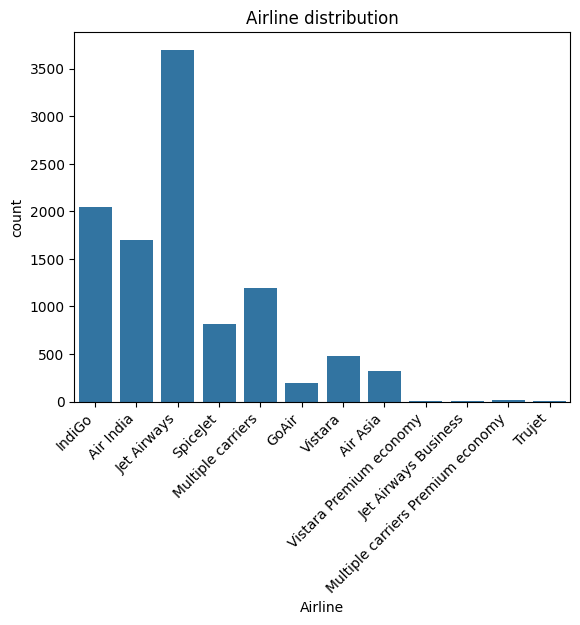

In [88]:
sns.countplot(data=df, x='Airline')
plt.xticks(rotation=45, ha='right')
plt.title('Airline distribution')

Visualizes the volume of flights per airline, showing that Jet Airways and Indigo operate the highest number of flights in this dataset.

In [89]:
df['Airline'].value_counts()

,count
Airline,
Jet Airways,3700
IndiGo,2043
Air India,1694
Multiple carriers,1196
SpiceJet,815
Vistara,478
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


Text(0.5, 1.0, 'Flights as per month')

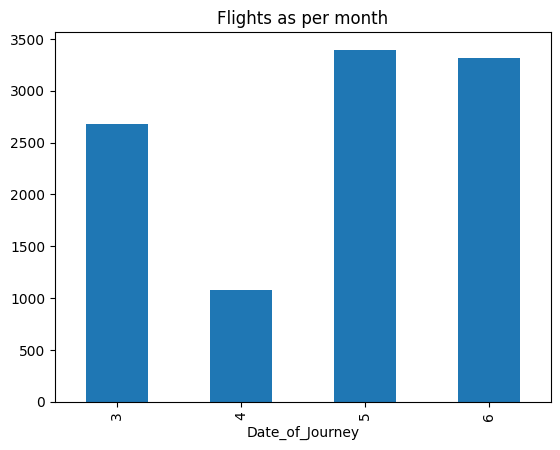

In [90]:
df['Date_of_Journey'].dt.month.value_counts().sort_index().plot(kind='bar')
plt.title('Flights as per month')

This graph shows the volume of flights per month. This dataset contains data of 4 months(March,April,May and June), where it is observed that there are more number of flights in may and june, which could be due to the fact that people go to vacations in these months more than usual.

Text(0.5, 1.0, 'Source distribution')

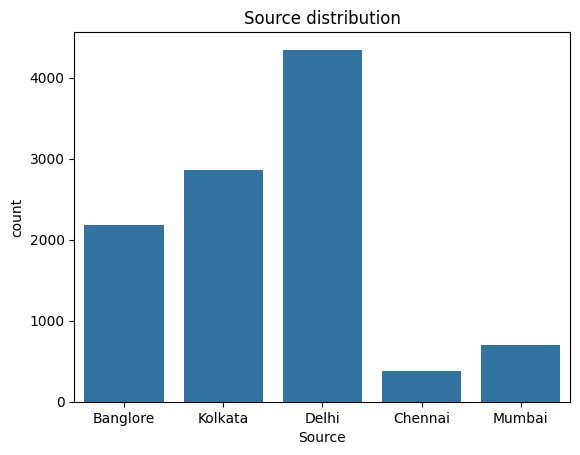

In [91]:
sns.countplot(data=df, x='Source')
plt.title('Source distribution')

Text(0.5, 1.0, 'Destination distribution')

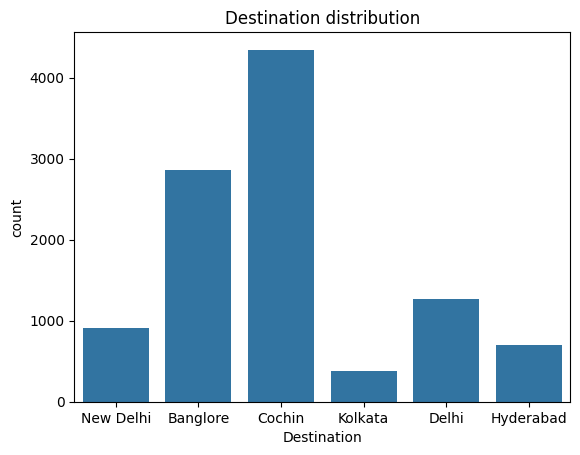

In [92]:
sns.countplot(data=df, x='Destination')
plt.title('Destination distribution')

These two graphs show the busiest departure and arrival hubs, showing Delhi as the top source and Cochin as the top destination.  

Text(0.5, 1.0, 'Duration distribution')

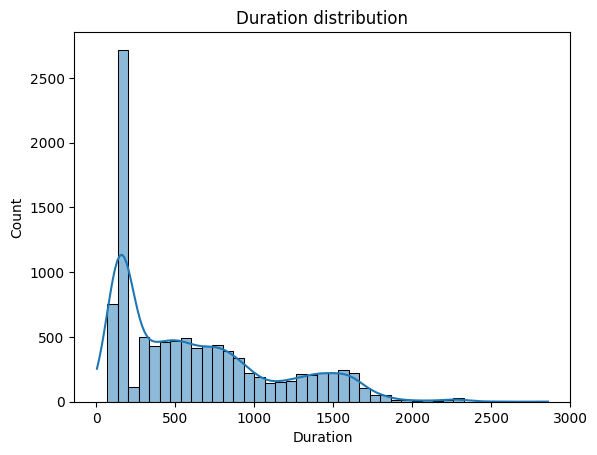

In [93]:
sns.histplot(df['Duration'],kde=True)
plt.title('Duration distribution')

Shows the distribution of flight times. The right-skewed shape indicates most flights are short domestic flights, with a long tail of longer, multi-stop flights.

<Axes: ylabel='Duration'>

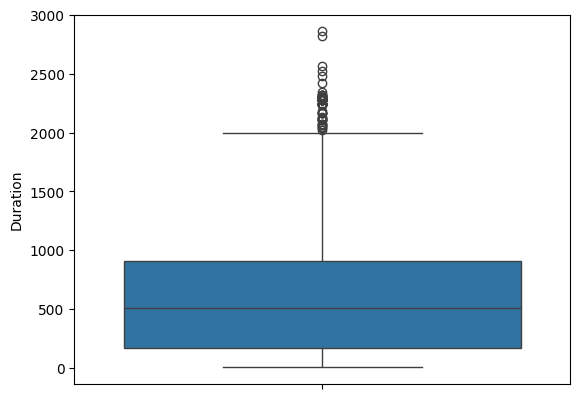

In [94]:
sns.boxplot(df['Duration'])

This boxplot gives us a 5 number summary, and also provides a look into outliers, here we could see the minimum duration seems to be very less, while the maximum duration is around 3000mins.

In [95]:
df['Duration'].min()

5

Checking the minimum duration of a flight, which is unsually 5 mins. This is an data entry error.

In [96]:
df[df['Duration'] == 5]

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_1,Layover_2
6474,Air India,2019-03-06,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,5,2,No info,17327,16:50:00,16:55:00,GOI,PNQ


In [97]:
df.loc[df['Duration'] == 5, 'Duration'] = 1445

 FOR THE DISCREPENCY IN THE DURATION COLUMN WITH A VALUE OF 5MIN, AS PER THE ANALYSIS THE FLIGHT REACHED THE NEXT DAY 4:55PM
HENCE WE WILL MANUALLY CORRECT THIS ENTRY

In [98]:
df.loc[6474]

,6474
Airline,Air India
Date_of_Journey,2019-03-06 00:00:00
Source,Mumbai
Destination,Hyderabad
Route,BOM → GOI → PNQ → HYD
Duration,1445
Total_Stops,2
Additional_Info,No info
Price,17327
Departure_Time,16:50:00


Text(0.5, 1.0, 'Total Stops')

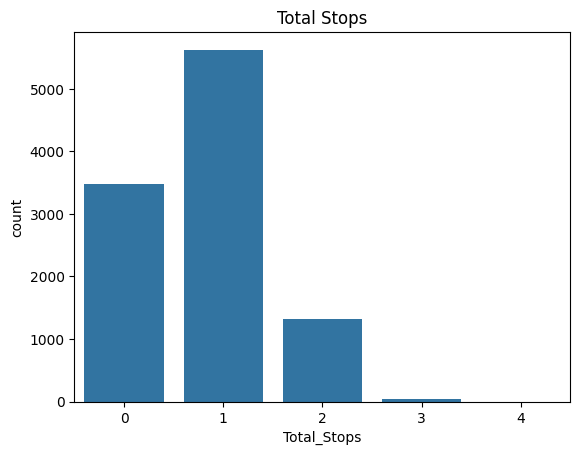

In [99]:
sns.countplot(data=df, x='Total_Stops')
plt.title('Total Stops')

Shows that flights with exactly 1 stop are the most common itinerary in the dataset.

Text(0.5, 1.0, 'Price distribution')

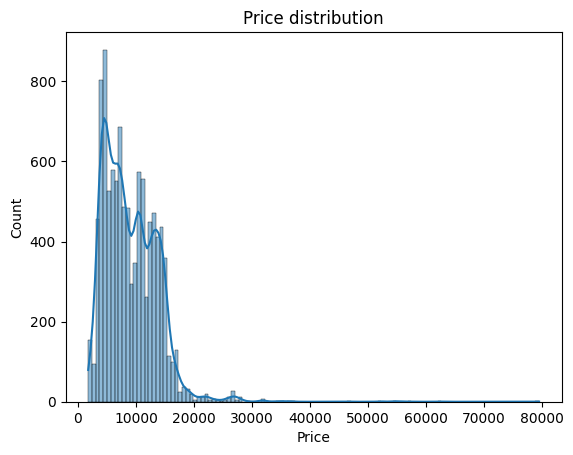

In [100]:
sns.histplot(df['Price'],kde=True)
plt.title('Price distribution')

Visualizes the distribution of ticket prices. The heavy right-skew shows that most tickets fall into a lower standard fare range, while a small number of premium or last-minute tickets drive the tail into very high prices.

<Axes: ylabel='Price'>

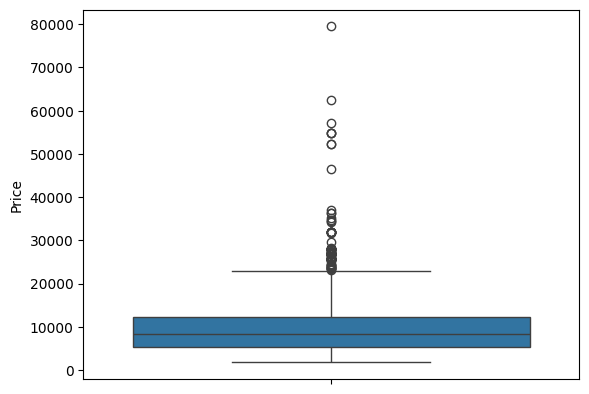

In [101]:
sns.boxplot(df['Price'])

This boxplot shows that majority of the fares are roughly between 5000 to 15000, there is a significant number of outliers, which are usually premium tickets(business class) or last minute bookings.

In [102]:
df['Price'].describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


<Axes: xlabel='Departure_Time'>

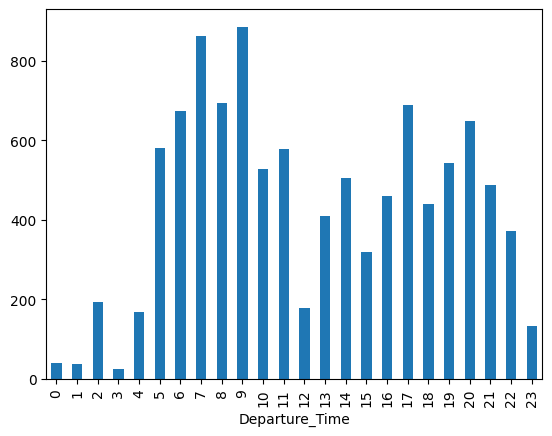

In [103]:
df['Departure_Time'].apply(lambda t: t.hour).value_counts().sort_index().plot(kind='bar')

This graphs suggests departures peak significantly in the morning between 7:00 AM and 9:00 AM, and again in the evening between 5:00 PM and 7:00 PM, while departures from midnight to 4 AM are quite rare.

<Axes: xlabel='Arrival_Time_'>

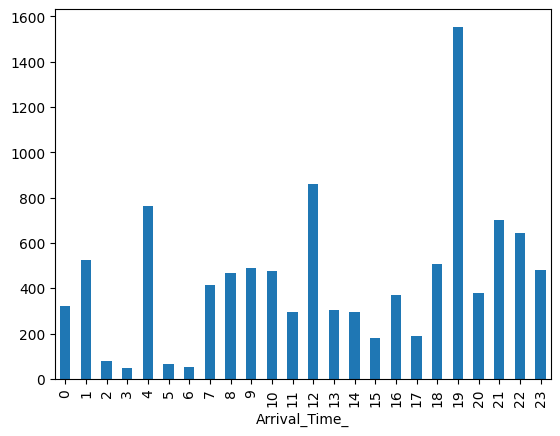

In [104]:
df['Arrival_Time_'].apply(lambda t: t.hour).value_counts().sort_index().plot(kind='bar')

Arrivals show a massive, singular spike at 7:00 PM.Secondary arrival peaks occur around noon and 9:00 PM.

Text(0.5, 1.0, 'Top 10 Layover_1 city distribution')

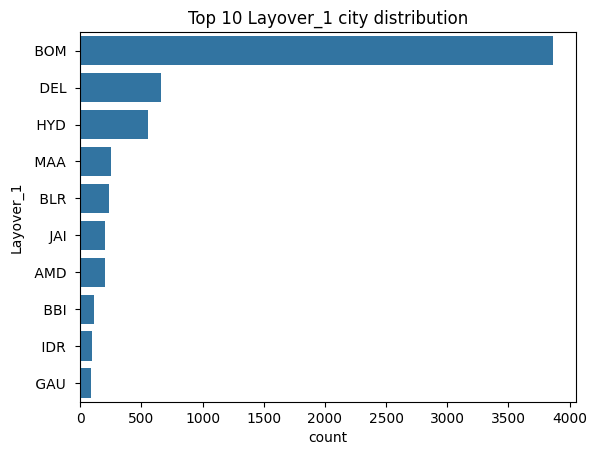

In [105]:
sns.countplot(data=df, y=df['Layover_1'].dropna(),order=df['Layover_1'].value_counts().index[:10])
plt.title('Top 10 Layover_1 city distribution')

Text(0.5, 1.0, 'Top 10 Layover_2 city distribution')

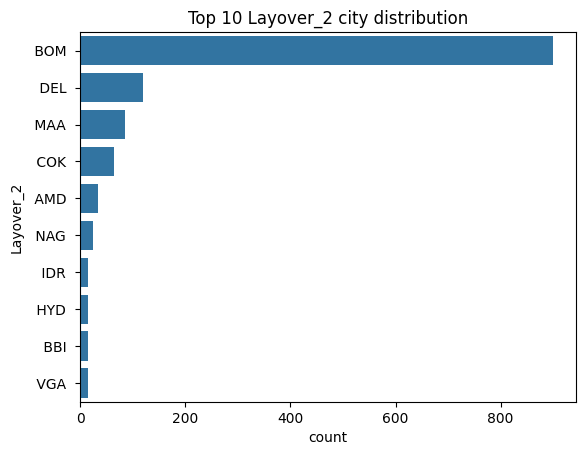

In [106]:
sns.countplot(data=df, y=df['Layover_2'].dropna(), order=df['Layover_2'].value_counts().index[:10])
plt.title('Top 10 Layover_2 city distribution')

Mumbai (BOM) is the primary connecting hub for these flights. It is the most frequent city for both the first layover stop and the second layover stop by a very large margin. Delhi (DEL) acts as the secondary connecting hub, consistently ranking as the second most common layover location for both the first and second stops, though its volume is very less as compared to Mumbai.

In [107]:
#Outlier Handling
Q1, Q3 = df['Price'].quantile(0.25), df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
df['Price_capped'] = df['Price'].clip(upper=upper)

In [108]:
(df['Price'] > upper).sum()

np.int64(94)

<Axes: ylabel='Price_capped'>

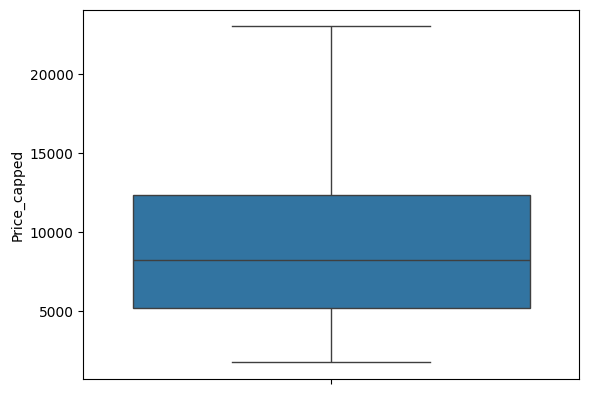

In [109]:
sns.boxplot(df['Price_capped'])

To handle those extremely high flight prices without completely throwing away the data, we used the IQR method to cap them. By finding the 25th and 75th percentiles, we calculated the interquartile range and set a strict upper boundary using the standard formula. Instead of dropping the rows that exceeded this limit, we used the clip function to just pull those 94 extreme outliers down to match our upper threshold exactly, storing the cleaned data in a new column called 'Price_capped'. As you can see in the final boxplot, doing this completely removes those high fare outliers and leaves us with a much cleaner distribution of ticket prices.

## Univariate Insights Summary

1. The highest used airline in jet airways with the second one being indigo.
2. This is a dataset of 4 months from march to june, where in may and june, there were more flights, it maybe so beacuse in these month people often go to vacations or their hometowns.
3. Most of the flight sources were from delhi and the most destination was Cochin, which states that delhi-cochin route is the most dominated in this dataset.
4. The median duartion of a flight in this data is 8hrs and where there outliers reaching to 50hrs and min of 5 mins which is what i think is mis calculated as the flight starts at 4:50 and would have reached destination the next day at 4:55.
5. Most of the flights have 1 followed by no stops.
6. Usually price is distributed around 6k to 15k around with a mean of 9k and outliers going till 80k.
7. Departure time is high in the morning (6-11am) and in the evening (5-9pm) while the Arrival Time has sharp spikes at 4am,12 noon and 7pm.
8. BOM(Mumbai) is the highest layover city for most of the flights

# Bivariate Analysis

In [110]:
df.corr(numeric_only=True)['Price']

,Price
Duration,0.502225
Total_Stops,0.602013
Price,1.000000
Price_capped,0.969918


Text(0.5, 1.0, 'Price vs Total_Stops')

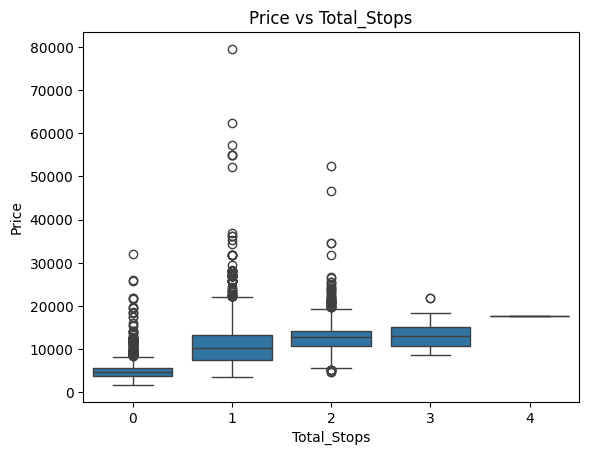

In [111]:
sns.boxplot(data=df, x='Total_Stops', y='Price')
plt.title('Price vs Total_Stops')

In [112]:
df[df['Airline']=='Jet Airways Business']

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Departure_Time,Arrival_Time_,Layover_1,Layover_2,Price_capped
657,Jet Airways Business,2019-03-01,Banglore,New Delhi,BLR → BOM → DEL,300,1,No info,52229,05:45:00,10:45:00,BOM,NaN,23025.875
2924,Jet Airways Business,2019-03-01,Banglore,New Delhi,BLR → BOM → DEL,340,1,Business class,79512,05:45:00,11:25:00,BOM,NaN,23025.875
5372,Jet Airways Business,2019-03-01,Banglore,New Delhi,BLR → BOM → DEL,400,1,Business class,62427,05:45:00,12:25:00,BOM,NaN,23025.875
7351,Jet Airways Business,2019-03-03,Delhi,Cochin,DEL → ATQ → BOM → COK,500,2,No info,46490,20:05:00,04:25:00,ATQ,BOM,23025.875
9715,Jet Airways Business,2019-03-06,Delhi,Cochin,DEL → ATQ → BOM → COK,500,2,No info,52285,20:05:00,04:25:00,ATQ,BOM,23025.875
10364,Jet Airways Business,2019-03-01,Banglore,New Delhi,BLR → MAA → DEL,280,1,Business class,57209,09:45:00,14:25:00,MAA,NaN,23025.875


This graph shows us that the median price increases with the number of stops increasing. But all those outliers in the 1 and 2 stop flights are the Jet Airways Business class, which do not depend upon the number of stops, rather it is a service price.

Text(0.5, 1.0, 'Price vs Airline')

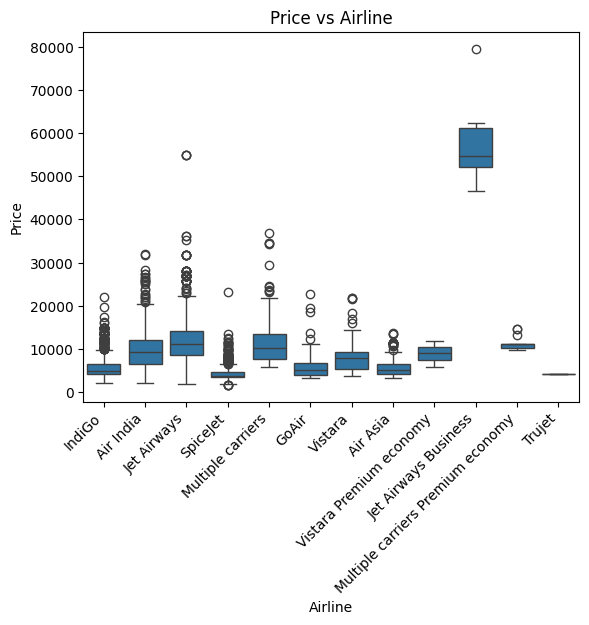

In [113]:
sns.boxplot(data=df, x='Airline', y='Price')
plt.xticks(rotation=45, ha='right')
plt.title('Price vs Airline')

This graph confirms the analysis from the above, that those price outliers are the Jet Airways Business class tickets. They have a median of 50-55k. While the normal Jet Airways ticket is quite normal.

Text(0.5, 1.0, 'Price vs Duration')

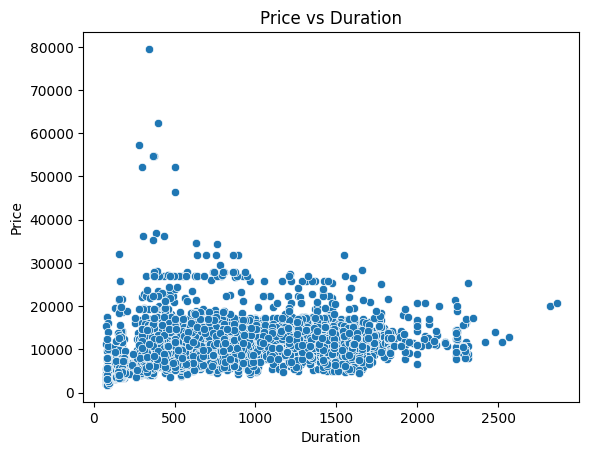

In [114]:
sns.scatterplot(data=df, x='Duration', y='Price')
plt.title('Price vs Duration')

The vast majority of flights are concentrated at prices under 20000 and durations under 1500, showing a dense baseline of standard fares. The most extreme, high-priced outliers (tickets of 40,000 and 80,000) do not occur on the absolute longest flights, instead they are clustered at lower to moderate durations between roughly 250 and 750.

Text(0.5, 1.0, 'Correlation heatmap')

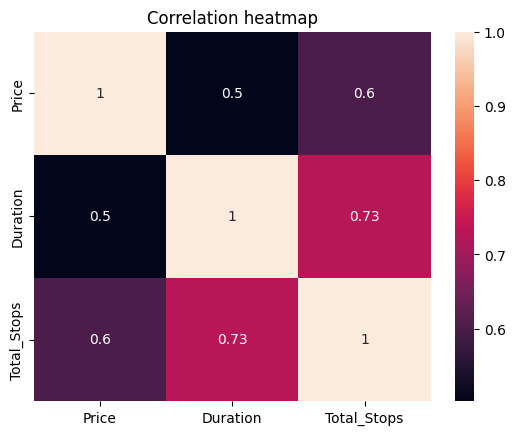

In [115]:
numeric_colms = ['Price', 'Duration', 'Total_Stops']
sns.heatmap(df[numeric_colms].corr(), annot=True)
plt.title('Correlation heatmap')

This Correlation heatmap helps us understand the correalation between Price, Duration and Total_Stops of the flights. Total_Stops has a stronger correlation with flight price (0.6) than the raw duration of the flight does (0.5). Flight duration and total stops are heavily correlated (0.73), indicating that longer flight times in this dataset are primarily the result of additional layovers rather than extended direct flight distances.

In [116]:
delhi_cochin = df[(df['Source']=='Delhi') & (df['Destination']=='Cochin')]
print(delhi_cochin['Arrival_Time_'].apply(lambda t: t.hour).value_counts().sort_index())

Arrival_Time_
0       15
1      437
3       15
4      513
6       19
7      178
8       82
9      148
10      18
11      27
12     466
13     105
14      30
15      61
16     105
17      75
18     153
19    1199
20      11
21     419
22     222
23      47
Name: count, dtype: int64


Arrivals for flights traveling from Delhi to Cochin are highly concentrated at specific times rather than being evenly distributed throughout the day. The most common arrival time by a huge margin is 7:00 PM

Text(0.5, 1.0, 'Price vs Layover_1 (top 10)')

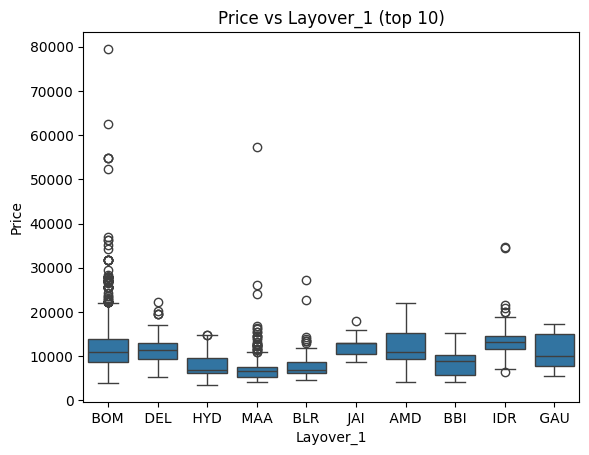

In [117]:
top_layovers = df['Layover_1'].value_counts().index[:10]
sns.boxplot(data=df[df['Layover_1'].isin(top_layovers)], x='Layover_1', y='Price', order=top_layovers)
plt.title('Price vs Layover_1 (top 10)')

When examining the top 10 first layover cities, flights routing through Mumbai (BOM) exhibit the widest overall price variation and contain the most extreme pricing outliers, going upto nearly 80,000.

## Bivariate Insights Summary
1. Total_Stops is the strongest price driver among numeric features median Price rises consistently with stops, and correlates with Price at 0.6, higher than Duration's 0.5.
2. The most extreme price outliers aren't explained by stops or duration at all they're a single distinct group, 6 Jet Airways Business class rows, sitting at ₹50k–80k regardless of stop count or trip length. This was confirmed independently across three separate charts (Price vs Total_Stops, Price vs Airline, Price vs Layover_1), which is what makes it a solid finding rather than a one-off observation.
3. Price vs Duration is not a simple straight-line relationship. Below 800 minutes, prices scatter across the full range (including the single highest fare in the dataset). Beyond 1500 minutes, the spread actually narrows into a tighter mid-price band.
4. Duration and Total_Stops are themselves highly correlated (0.73), largely overlapping information, since more stops naturally means more total travel time.
5. The dominant 7 PM arrival spike seen in univariate EDA isn't a general pattern, it's one route. Around 75% of all 7 PM arrivals in the entire dataset come from the Delhi-Cochin route alone. This reframes what looked like a broad daily pattern into a route-specific thing.
6. Mumbai (BOM) as a layover hub shows the widest price spread and carries the same outlier cluster consistent with the Jet Airways Business flights routing through it, not a separate effect.